# BiLSTM

# yelp

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.5565, Val Acc: 0.6639, Test Acc: 0.6794
Epoch 2, Train Acc: 0.6527, Val Acc: 0.6942, Test Acc: 0.6994
Epoch 3, Train Acc: 0.6849, Val Acc: 0.6836, Test Acc: 0.6986
Epoch 4, Train Acc: 0.7141, Val Acc: 0.6789, Test Acc: 0.7011
Epoch 5, Train Acc: 0.7379, Val Acc: 0.6750, Test Acc: 0.7006
Epoch 6, Train Acc: 0.7926, Val Acc: 0.6750, Test Acc: 0.6950
Epoch 7, Train Acc: 0.8124, Val Acc: 0.6550, Test Acc: 0.6858
Epoch 8, Train Acc: 0.8291, Val Acc: 0.6639, Test Acc: 0.6961
Epoch 9, Train Acc: 0.8616, Val Acc: 0.6522, Test Acc: 0.6900
Epoch 10, Train Acc: 0.8731, Val Acc: 0.6575, Test Acc: 0.6864
Epoch 11, Train Acc: 0.8836, Val Acc: 0.6431, Test Acc: 0.6828
Epoch 12, Train Acc: 0.8968, Val Acc: 0.6417, Test Acc: 0.6739
Epoch 13, Train Acc: 0.9035, Val Acc: 0.6481, Test Acc: 0.6747
Epoch 14, Train Acc: 0.9077, Val Acc: 0.6367, Test Acc: 0.6719
Epoch 15, Train Acc: 0.9155, Val Acc: 0.6319, Test Acc: 0.6664
Epoch 16, Train Acc: 0.9187, Val Acc: 0.6361, Test Acc: 0.6714
E

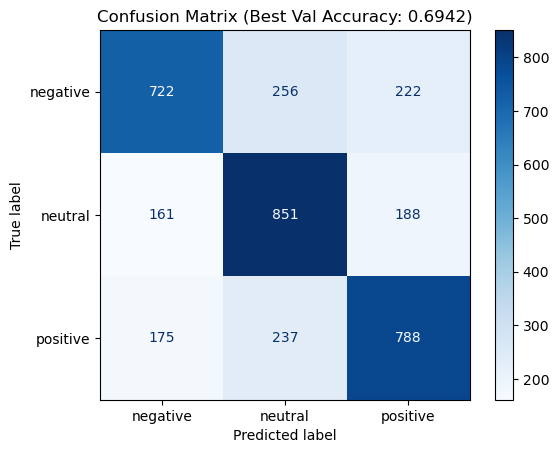

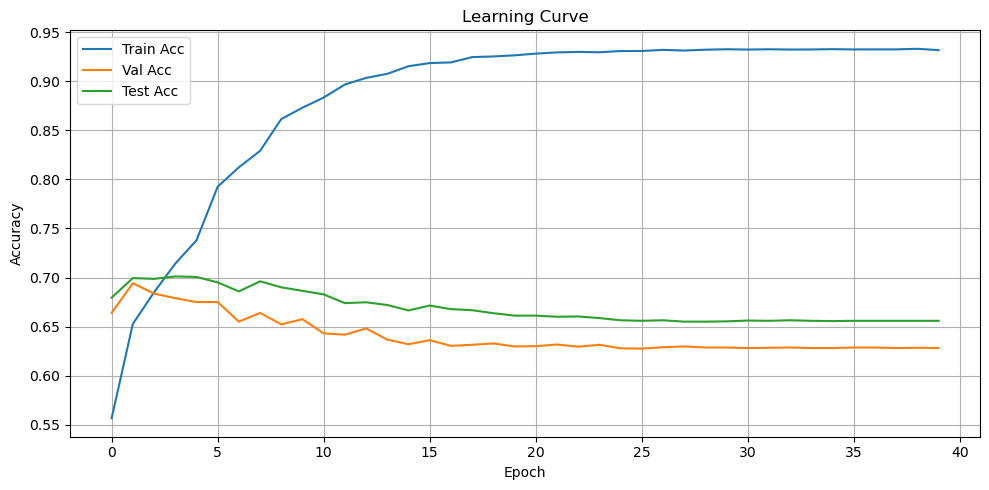

In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/yelp/train.csv"
val_file = "/Users/tejamallireddy/Downloads/yelp/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/yelp/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# ------------------- Preprocess -------------------
for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)  # ↓ batch size for better generalization
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# ------------------- BiLSTM Model -------------------
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, num_classes):
        super(BiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = True  # fine-tune GloVe
        self.lstm = nn.LSTM(embed_size, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)  # (batch, seq_len, embed_dim)
        _, (hidden, _) = self.lstm(x)  # hidden: (2, batch, hidden_dim)
        out = torch.cat((hidden[0], hidden[1]), dim=1)  # concat forward and backward
        out = self.dropout(out)
        return self.fc(out)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTM(len(vocab) + 1, 300, 128, len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

def train_model(model, train_loader, val_loader, test_loader, epochs=40):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)
        scheduler.step(val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# dynabench

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.3442, Val Acc: 0.3944, Test Acc: 0.3861
Epoch 2, Train Acc: 0.4670, Val Acc: 0.5056, Test Acc: 0.5444
Epoch 3, Train Acc: 0.6767, Val Acc: 0.5639, Test Acc: 0.6069
Epoch 4, Train Acc: 0.7760, Val Acc: 0.5597, Test Acc: 0.5958
Epoch 5, Train Acc: 0.8395, Val Acc: 0.5819, Test Acc: 0.6139
Epoch 6, Train Acc: 0.8755, Val Acc: 0.5792, Test Acc: 0.6125
Epoch 7, Train Acc: 0.9090, Val Acc: 0.5625, Test Acc: 0.6167
Epoch 8, Train Acc: 0.9315, Val Acc: 0.5569, Test Acc: 0.6083
Epoch 9, Train Acc: 0.9417, Val Acc: 0.5542, Test Acc: 0.5958
Epoch 10, Train Acc: 0.9461, Val Acc: 0.5653, Test Acc: 0.6042
Epoch 11, Train Acc: 0.9508, Val Acc: 0.5653, Test Acc: 0.6042
Epoch 12, Train Acc: 0.9495, Val Acc: 0.5569, Test Acc: 0.6042
Epoch 13, Train Acc: 0.9503, Val Acc: 0.5639, Test Acc: 0.6139
Epoch 14, Train Acc: 0.9465, Val Acc: 0.5597, Test Acc: 0.5889
Epoch 15, Train Acc: 0.9498, Val Acc: 0.5639, Test Acc: 0.6069
Epoch 16, Train Acc: 0.9473, Val Acc: 0.5639, Test Acc: 0.5986
E

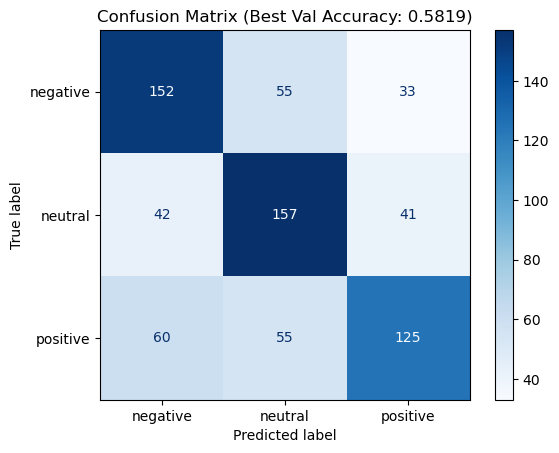

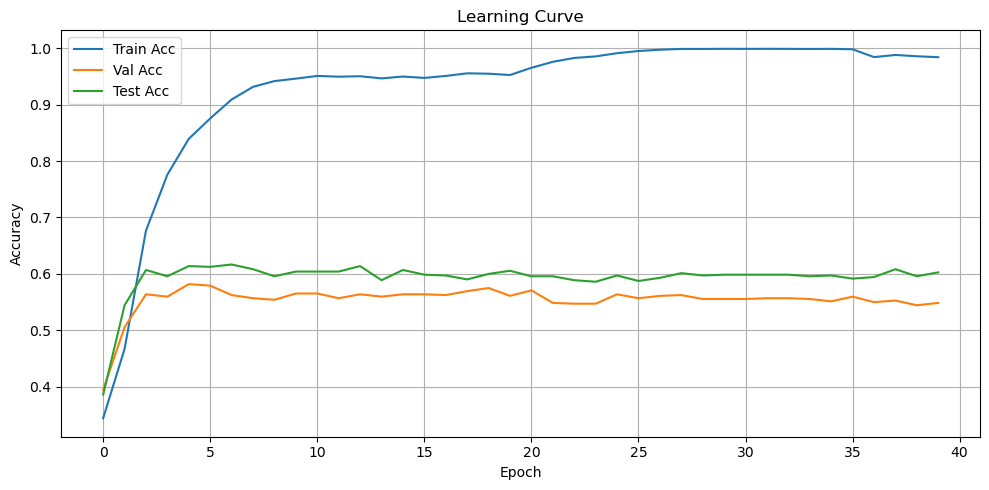

In [18]:
# ------------------- IMPORTS -------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/dynabench/train.csv"
val_file = "/Users/tejamallireddy/Downloads/dynabench/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/dynabench/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# ------------------- BiLSTM + Self-Attn Model -------------------
class ScaledDotAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = dim ** -0.5
    def forward(self, x):
        scores = torch.matmul(x, x.transpose(1, 2)) * self.scale
        weights = torch.softmax(scores, dim=-1)
        return torch.matmul(weights, x)

class BiLSTM_Attn(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = True
        self.lstm = nn.LSTM(embed_size, hidden_dim, batch_first=True, bidirectional=True, num_layers=2)
        self.attn = ScaledDotAttention(hidden_dim * 2)
        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        attn_out = self.attn(lstm_out)
        context = torch.mean(attn_out, dim=1)
        context = self.norm(context)
        context = self.dropout(context)
        return self.fc(context)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTM_Attn(len(vocab) + 1, 300, 128, len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def train_model(model, train_loader, val_loader, test_loader, epochs=40):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)
        scheduler.step()

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# yelp_dynabench_2500

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.5584, Val Acc: 0.6194, Test Acc: 0.6340
Epoch 2, Train Acc: 0.6906, Val Acc: 0.6382, Test Acc: 0.6507
Epoch 3, Train Acc: 0.7553, Val Acc: 0.6431, Test Acc: 0.6514
Epoch 4, Train Acc: 0.8117, Val Acc: 0.6257, Test Acc: 0.6458
Epoch 5, Train Acc: 0.8526, Val Acc: 0.6340, Test Acc: 0.6486
Epoch 6, Train Acc: 0.8848, Val Acc: 0.6250, Test Acc: 0.6549
Epoch 7, Train Acc: 0.9088, Val Acc: 0.6188, Test Acc: 0.6479
Epoch 8, Train Acc: 0.9278, Val Acc: 0.6174, Test Acc: 0.6396
Epoch 9, Train Acc: 0.9417, Val Acc: 0.6160, Test Acc: 0.6326
Epoch 10, Train Acc: 0.9497, Val Acc: 0.6153, Test Acc: 0.6326
Epoch 11, Train Acc: 0.9516, Val Acc: 0.6153, Test Acc: 0.6326
Epoch 12, Train Acc: 0.9509, Val Acc: 0.6146, Test Acc: 0.6312
Epoch 13, Train Acc: 0.9501, Val Acc: 0.6111, Test Acc: 0.6354
Epoch 14, Train Acc: 0.9493, Val Acc: 0.6090, Test Acc: 0.6194
Epoch 15, Train Acc: 0.9462, Val Acc: 0.6181, Test Acc: 0.6250
Epoch 16, Train Acc: 0.9448, Val Acc: 0.6132, Test Acc: 0.6326
E

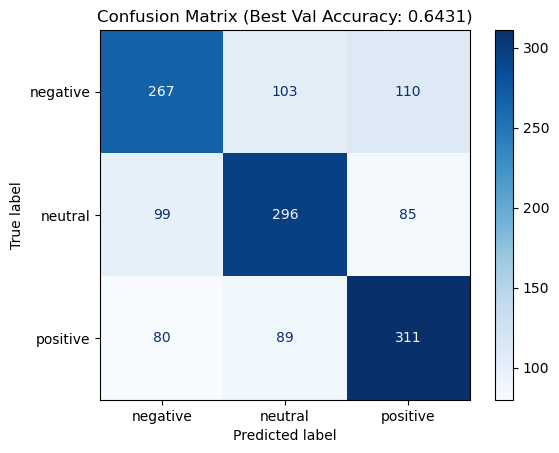

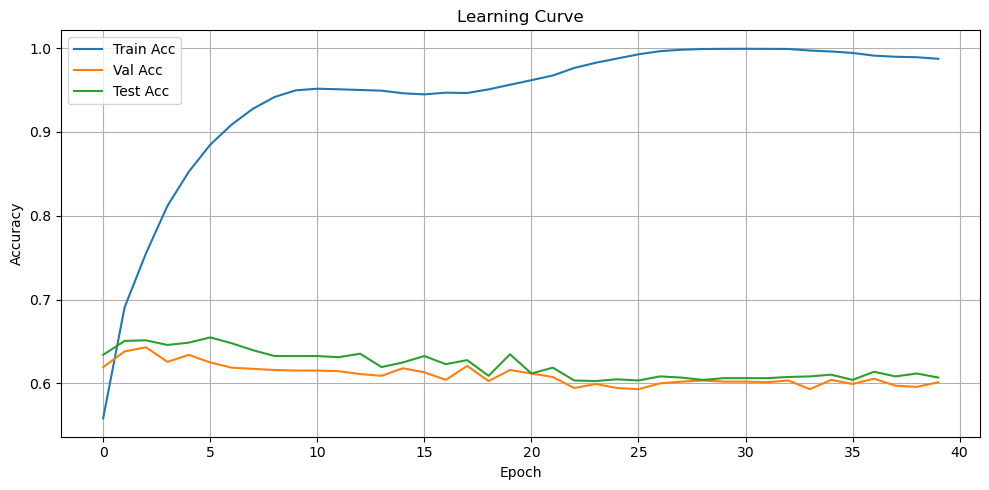

In [21]:
# ------------------- IMPORTS -------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/train.csv"
val_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# ------------------- BiLSTM + Self-Attn Model -------------------
class ScaledDotAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = dim ** -0.5
    def forward(self, x):
        scores = torch.matmul(x, x.transpose(1, 2)) * self.scale
        weights = torch.softmax(scores, dim=-1)
        return torch.matmul(weights, x)

class BiLSTM_Attn(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = True
        self.lstm = nn.LSTM(embed_size, hidden_dim, batch_first=True, bidirectional=True, num_layers=2)
        self.attn = ScaledDotAttention(hidden_dim * 2)
        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        attn_out = self.attn(lstm_out)
        context = torch.mean(attn_out, dim=1)
        context = self.norm(context)
        context = self.dropout(context)
        return self.fc(context)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTM_Attn(len(vocab) + 1, 300, 128, len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def train_model(model, train_loader, val_loader, test_loader, epochs=40):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)
        scheduler.step()

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)
